# Bathymetry Pipeline Overview

This notebook walks through the `set_from_dataset` pipeline from first principles using a **small synthetic toy problem** — a 5×4 model grid with a hand-crafted source bathymetry.

## The two pipelines

`set_from_dataset` dispatches to one of two pipelines based on how much finer the source grid is than the model grid:

| Ratio (source/model) | Pipeline | When to use |
|---|---|---|
| ≥ 12× | `high_res_regrid` | Coarse model grid (≳ 0.05°), GEBCO-class source |
| < 12× | `direct_xesmf_regrid` | Fine model grid, source and model at similar resolution |

### High-res pipeline
```
SourceBathy → generate_mask (ocean_frac or cartopy) → cressman_interp → tidy_dataset
```

### Direct pipeline  
```
SourceBathy → xesmf regrid → tidy_dataset (mask derived from depth sign or pre-computed)
```

We walk through **both** by hand below so you can see exactly what each step does.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from pathlib import Path
import tempfile

from mom6_forge.grid import Grid
from mom6_forge.topo import Topo
from mom6_forge._source_bathy import SourceBathy

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

## 1. Build the toy model grid

A 5×4 T-cell grid over a small Gulf of Mexico sub-domain at 2° resolution.
This is deliberately coarse so that the high-res ratio condition is met with a modest source file.

In [2]:
grid = Grid(
    resolution=2.0,   # 2° model grid
    xstart=262.0,
    lenx=10.0,        # 5 cells wide
    ystart=20.0,
    leny=8.0,         # 4 cells tall
    name="toy",
)

print(f"Model grid: {grid.nx} × {grid.ny} T-cells")
print(f"T-cell lon range: {float(grid.tlon.min()):.1f} – {float(grid.tlon.max()):.1f}")
print(f"T-cell lat range: {float(grid.tlat.min()):.1f} – {float(grid.tlat.max()):.1f}")

Model grid: 5 × 4 T-cells
T-cell lon range: 263.0 – 271.0
T-cell lat range: 21.0 – 27.0


## 2. Build the synthetic source bathymetry

We create a synthetic GEBCO-style file at 0.1° resolution (~20× finer than the model grid).
The elevation convention matches GEBCO: **negative = ocean, positive = land**.

We add:
- A land peninsula in the NW corner
- A shallow bank in the center
- Deep ocean everywhere else

In [3]:
# Source grid: 0.1° resolution, covers the model domain with margin
src_lons = np.arange(260.0, 274.1, 0.1)
src_lats = np.arange(18.0,  30.1, 0.1)
src_lon2d, src_lat2d = np.meshgrid(src_lons, src_lats)

# Start with uniform deep ocean (-2000 m elevation = 2000 m depth)
elevation = np.full(src_lon2d.shape, -2000.0)

# Land peninsula: NW corner (lon < 265, lat > 26)
elevation[(src_lat2d > 26.0) & (src_lon2d < 265.0)] = +50.0

# Shallow bank: center of domain (depth = 80 m)
elevation[
    (src_lat2d > 22.0) & (src_lat2d < 24.0) &
    (src_lon2d > 266.0) & (src_lon2d < 268.0)
] = -80.0

ds_src = xr.Dataset(
    {"elevation": (["lat", "lon"], elevation.astype("float32"))},
    coords={"lon": src_lons, "lat": src_lats},
)
ds_src.elevation.attrs["units"] = "m"

# Write to a temp file so SourceBathy can load it
tmp_dir = Path(tempfile.mkdtemp())
src_path = tmp_dir / "synthetic_bathy.nc"
ds_src.to_netcdf(src_path)

print(f"Source grid: {len(src_lons)} × {len(src_lats)} pixels at 0.1°")
print(f"Approx source/model ratio: {0.1/2.0:.1f}× (wait — that's backwards)")
print(f"Approx model/source ratio: {2.0/0.1:.0f}× finer source than model")

Source grid: 142 × 122 pixels at 0.1°
Approx source/model ratio: 0.1× (wait — that's backwards)
Approx model/source ratio: 20× finer source than model


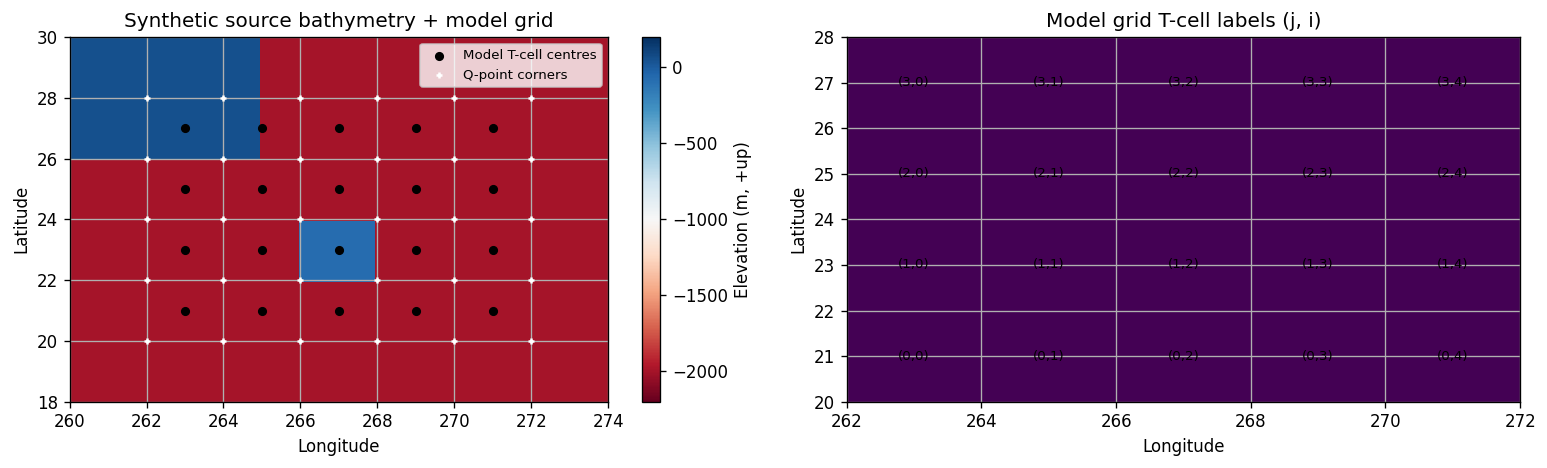

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Source bathymetry ---
ax = axes[0]
c = ax.pcolormesh(
    src_lons, src_lats, elevation,
    cmap="RdBu", vmin=-2200, vmax=200, shading="auto"
)
plt.colorbar(c, ax=ax, label="Elevation (m, +up)")
# Overlay model grid T-cell centres
ax.scatter(
    grid.tlon.values.ravel(), grid.tlat.values.ravel(),
    c="k", s=20, zorder=5, label="Model T-cell centres"
)
# Overlay model grid Q-point corners
ax.scatter(
    grid.qlon.values.ravel(), grid.qlat.values.ravel(),
    c="white", s=10, marker="+", zorder=5, label="Q-point corners"
)
ax.set_title("Synthetic source bathymetry + model grid")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=8)
ax.set_xlim(260, 274)
ax.set_ylim(18, 30)

# --- Model grid with labels ---
ax = axes[1]
ax.set_title("Model grid T-cell labels (j, i)")
tlons = grid.tlon.values
tlats = grid.tlat.values
ax.pcolormesh(
    grid.qlon.values, grid.qlat.values,
    np.ones((grid.ny, grid.nx)),
    edgecolors="k", linewidth=0.5, facecolor="lightblue", shading="flat"
)
for j in range(grid.ny):
    for i in range(grid.nx):
        ax.text(
            tlons[j, i], tlats[j, i], f"({j},{i})",
            ha="center", va="center", fontsize=8
        )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## 3. `diagnose_resolution` — which pipeline?

Before anything else, `set_from_dataset` calls `diagnose_resolution` to compare the average model cell spacing (km) against the source pixel spacing (km). If the source is ≥ 12× finer, it recommends the high-res pipeline.

In [5]:
topo = Topo(grid, min_depth=5.0, version_control_dir=tmp_dir)
topo.set_flat(1000)   # initialise with flat 1000 m ocean

src = SourceBathy(src_path).slice_to_domain(topo)

use_high_res = topo.diagnose_resolution(src)
print(f"diagnose_resolution → use high_res_regrid: {use_high_res}")

  Resolution Diagnostics

  Source dataset (synthetic_bathy.nc):
    dlon = 360.0 arcsec  (0.100000°)
    dlat = 360.0 arcsec  (0.100000°)
    dx   ~ 10158 m  (at domain mid-lat 24.0°)
    dy   ~ 11119 m

  Model grid (T-cell spacing):
    median = 213.38 km
    min    = 210.84 km
    max    = 215.64 km

  Resolution ratio (model dx / dataset dx):
    median = 21.0x
    max    = 21.2x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: high_res_regrid()  (Cressman + stats mask)
    Each model cell spans ~21 dataset pixels per side.
    Ocean-aware Cressman interpolation will meaningfully reduce
    land contamination of coastal depth estimates.
diagnose_resolution → use high_res_regrid: True


## 4. High-res pipeline — step by step

```
SourceBathy
  └─ generate_mask_ocean_frac   ← Monte-Carlo sub-sampling (mirrors create_model_topo.f90)
       └─ cressman_interp        ← Cressman distance-weighted interpolation (mirrors append_topo_interp_smooth.f90)
            └─ tidy_dataset       ← lake removal, channel fill, min-depth enforcement
```

### Step 4a: Generate the ocean mask

In [12]:
# nx_sub=ny_sub=3 → 3×3 = 9 sub-points per cell (keep small for the toy problem)
mask_of = topo.generate_mask_ocean_frac(src, nx_sub=3, ny_sub=3, mask_threshold=0.5)

print("ocean_frac mask:")
print(mask_of.values)
print(f"\n{int(mask_of.sum())} ocean cells, {int((1 - mask_of).sum())} land cells")


ocean_frac mask:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 1 1 1 1]]

19 ocean cells, 1 land cells


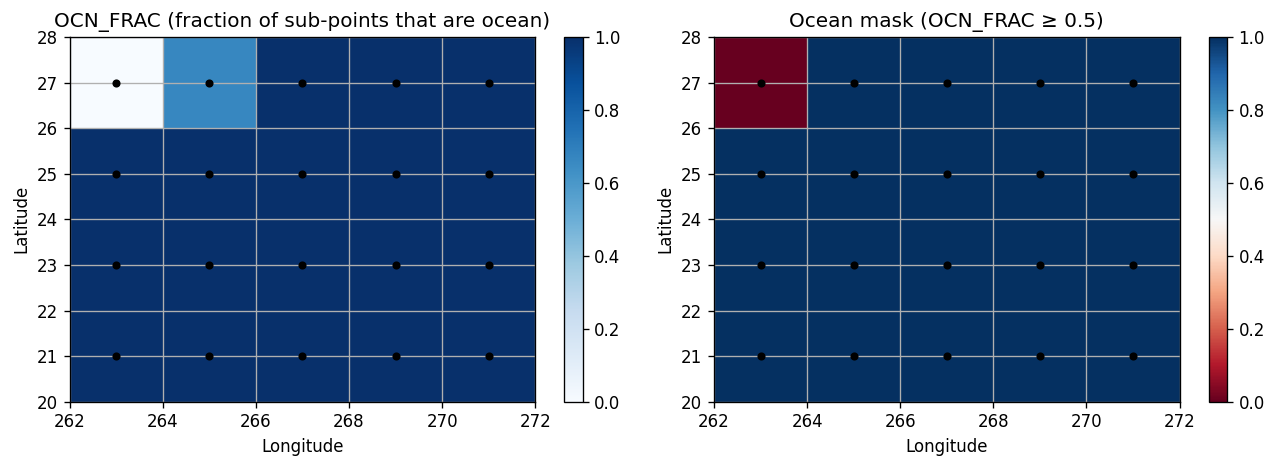

In [11]:
# Also look at the raw OCN_FRAC values before threshold
ocn_frac = src._topo_stats["OCN_FRAC"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, title, cmap, vmin, vmax in [
    (axes[0], ocn_frac, "OCN_FRAC (fraction of sub-points that are ocean)", "Blues", 0, 1),
    (axes[1], mask_of.values, "Ocean mask (OCN_FRAC ≥ 0.5)", "RdBu", 0, 1),
]:
    c = ax.pcolormesh(
        grid.qlon.values, grid.qlat.values, data,
        cmap=cmap, vmin=vmin, vmax=vmax, shading="flat"
    )
    plt.colorbar(c, ax=ax)
    ax.scatter(grid.tlon.values.ravel(), grid.tlat.values.ravel(), c="k", s=15, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

### Step 4b: Cressman interpolation

For each **ocean** model cell, gather all source ocean pixels within a radius
`L = smooth_scl × √(cell_area)` and compute a distance-weighted average:

$$w = \left(\frac{L^2 - r^2}{L^2 + r^2}\right)^{c}$$

The weights are precomputed via a KDTree on the source ocean pixels (see notebook 10 for details).

Computing Cressman weights…
Cressman weights written to /glade/derecho/scratch/manishrv/tmp/tmpxe6dd66z/cressman_weights.nc


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


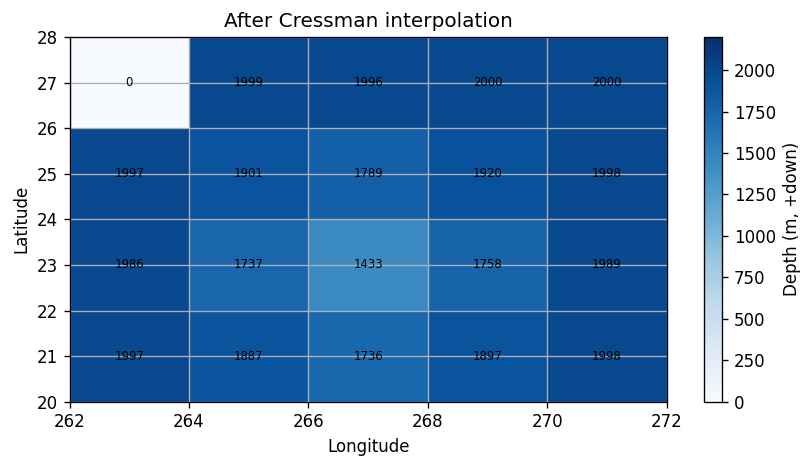

In [13]:
weights_path = tmp_dir / "cressman_weights.nc"
topo.cressman_interp(src, mask_of, smooth_scl=2.0, weights_path=weights_path)

depth_after_cressman = topo.depth.values.copy()

fig, ax = plt.subplots(figsize=(7, 4))
c = ax.pcolormesh(
    grid.qlon.values, grid.qlat.values, depth_after_cressman,
    cmap="Blues", vmin=0, vmax=2200, shading="flat"
)
plt.colorbar(c, ax=ax, label="Depth (m, +down)")
# Annotate each cell with its depth
for j in range(grid.ny):
    for i in range(grid.nx):
        ax.text(
            grid.tlon.values[j, i], grid.tlat.values[j, i],
            f"{depth_after_cressman[j, i]:.0f}",
            ha="center", va="center", fontsize=7, color="k"
        )
ax.set_title("After Cressman interpolation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Step 4c: `tidy_dataset`

`tidy_dataset` does three things after regridding:
1. **Lake removal** — `scipy.ndimage.binary_fill_holes` fills enclosed inland seas
2. **Channel fill** — removes single-cell-wide channels (optionally diagonal too)
3. **min_depth enforcement** — shallow ocean cells are clamped to `min_depth`

In the high-res pipeline `tidy_dataset` is called by `cressman_interp` internally, so the depth is already tidy. The cell below shows what the final depth looks like after the full pipeline.

In [14]:
print("Final depth grid (m):")
print(np.round(topo.depth.values, 1))
print(f"\nmin ocean depth: {topo.depth.values[topo.depth.values > 0].min():.1f} m")
print(f"max depth:       {topo.depth.values.max():.1f} m")

Final depth grid (m):
[[1996.6 1886.7 1735.9 1897.  1997.6]
 [1985.5 1736.6 1432.6 1758.3 1988.9]
 [1996.8 1900.7 1789.4 1919.7 1998.2]
 [   0.  1999.  1996.3 1999.5 2000. ]]

min ocean depth: 1432.6 m
max depth:       2000.0 m


## 5. Direct pipeline — step by step

```
SourceBathy
  └─ xesmf bilinear regrid         ← regrids source elevation onto model T-grid
       └─ tidy_dataset              ← sign correction, mask derivation, lake/channel cleanup
```

The direct pipeline is simpler — it uses `xesmf` for regridding and derives the mask from the sign of the regridded depth. This is appropriate when the source and model grids are at similar resolution (ratio < 12×).

To demonstrate it here we force the call even though our toy problem qualifies for high-res.

In [15]:
# Fresh topo for the direct pipeline
topo_direct = Topo(grid, min_depth=5.0, version_control_dir=tmp_dir)
topo_direct.set_flat(1000)

topo_direct.direct_xesmf_regrid(
    src,
    regridding_method="bilinear",
    positive_down=False,   # source is elevation (positive up)
)

depth_direct = topo_direct.depth.values.copy()

print("Direct pipeline final depth (m):")
print(np.round(depth_direct, 1))

Begin regridding dataset...

Original dataset size: 0.08 Mb
Regridded size: 0.00 Mb

Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... Direct pipeline final depth (m):
[[2000. 2000. 2000. 2000. 2000.]
 [2000. 2000.   80. 2000. 2000.]
 [2000. 2000. 2000. 2000. 2000.]
 [   0. 2000. 2000. 2000. 2000.]]


/glade/work/manishrv/conda-envs/mom6_forge/lib/python3.14/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


## 6. Side-by-side comparison

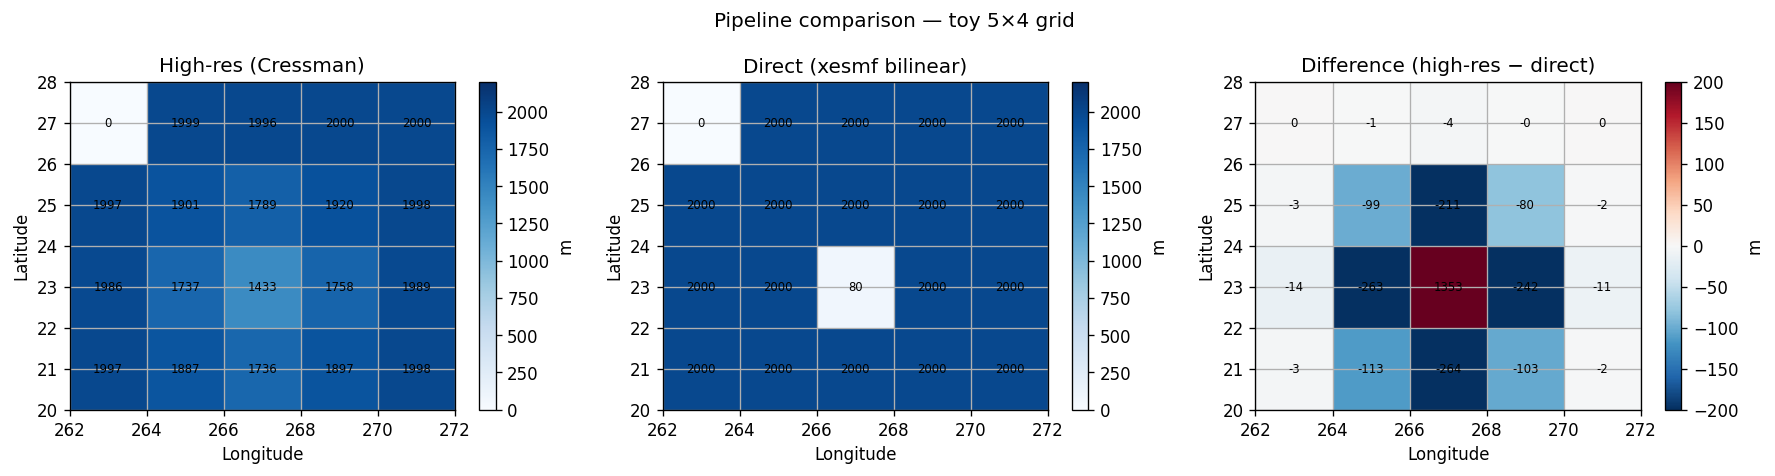

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vmax = 2200
datasets = [
    (depth_after_cressman, "High-res (Cressman)"),
    (depth_direct,         "Direct (xesmf bilinear)"),
    (depth_after_cressman - depth_direct, "Difference (high-res − direct)"),
]
cmaps  = ["Blues", "Blues", "RdBu_r"]
vmins  = [0, 0, -200]
vmaxes = [vmax, vmax, 200]

for ax, (data, title), cmap, vmin, vm in zip(axes, datasets, cmaps, vmins, vmaxes):
    c = ax.pcolormesh(
        grid.qlon.values, grid.qlat.values, data,
        cmap=cmap, vmin=vmin, vmax=vm, shading="flat"
    )
    plt.colorbar(c, ax=ax, label="m")
    for j in range(grid.ny):
        for i in range(grid.nx):
            ax.text(
                grid.tlon.values[j, i], grid.tlat.values[j, i],
                f"{data[j, i]:.0f}",
                ha="center", va="center", fontsize=7
            )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Pipeline comparison — toy 5×4 grid", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| | High-res (Cressman) | Direct (xesmf) |
|---|---|---|
| **Mask** | Monte-Carlo sub-sampling of source | Derived from regridded depth sign (or pre-computed) |
| **Depth** | Cressman distance-weighted average of source ocean pixels | xesmf bilinear interpolation |
| **Best for** | Coarse model grid (≳ 0.05°) with high-res source | Fine model grid or source/model at similar resolution |
| **Cost** | Higher (KDTree, weight matrix) | Lower (xesmf regrid only) |

The high-res pipeline produces a more faithful mask and avoids land-contamination of coastal depth estimates because it never interpolates land and ocean depths together. The direct pipeline is cheaper but can smear depths across coastlines.

**Next notebooks:**
- `9_mask_methods.ipynb` — deep dive into how each mask method works
- `10_cressman_interpolation.ipynb` — visualising the Cressman weights and KDTree
- `11_full_scale_example.ipynb` — production workflow with real GEBCO data